In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from newsapi import NewsApiClient
from textblob import TextBlob
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Your API Key ──────────────────────────────
NEWSAPI_KEY = "paste_your_key_here"
newsapi = NewsApiClient(api_key=NEWSAPI_KEY)

print("Libraries loaded ✅")
print(f"NewsAPI connected ✅")

Libraries loaded ✅
NewsAPI connected ✅


In [15]:
bank_names = {
    'JPM':    'JP Morgan',
    'GS':     'Goldman Sachs',
    'BARC.L': 'Barclays',
    'HSBA.L': 'HSBC',
    'MS':     'Morgan Stanley'
}

# ── Known earnings dates ──────────────────────────────────────
known_earnings = [
    {'ticker':'JPM',   'event_date':'2023-04-14','event_type':'Earnings Announcement','detail':'Q1 2023 Earnings'},
    {'ticker':'JPM',   'event_date':'2023-07-14','event_type':'Earnings Announcement','detail':'Q2 2023 Earnings'},
    {'ticker':'JPM',   'event_date':'2023-10-13','event_type':'Earnings Announcement','detail':'Q3 2023 Earnings'},
    {'ticker':'JPM',   'event_date':'2024-01-12','event_type':'Earnings Announcement','detail':'Q4 2023 Earnings'},
    {'ticker':'JPM',   'event_date':'2024-04-12','event_type':'Earnings Announcement','detail':'Q1 2024 Earnings'},
    {'ticker':'JPM',   'event_date':'2024-07-12','event_type':'Earnings Announcement','detail':'Q2 2024 Earnings'},
    {'ticker':'JPM',   'event_date':'2024-10-11','event_type':'Earnings Announcement','detail':'Q3 2024 Earnings'},
    {'ticker':'GS',    'event_date':'2023-04-18','event_type':'Earnings Announcement','detail':'Q1 2023 Earnings'},
    {'ticker':'GS',    'event_date':'2023-07-19','event_type':'Earnings Announcement','detail':'Q2 2023 Earnings'},
    {'ticker':'GS',    'event_date':'2023-10-17','event_type':'Earnings Announcement','detail':'Q3 2023 Earnings'},
    {'ticker':'GS',    'event_date':'2024-01-16','event_type':'Earnings Announcement','detail':'Q4 2023 Earnings'},
    {'ticker':'GS',    'event_date':'2024-04-15','event_type':'Earnings Announcement','detail':'Q1 2024 Earnings'},
    {'ticker':'GS',    'event_date':'2024-07-15','event_type':'Earnings Announcement','detail':'Q2 2024 Earnings'},
    {'ticker':'GS',    'event_date':'2024-10-15','event_type':'Earnings Announcement','detail':'Q3 2024 Earnings'},
    {'ticker':'BARC.L','event_date':'2023-02-15','event_type':'Earnings Announcement','detail':'FY 2022 Results'},
    {'ticker':'BARC.L','event_date':'2023-05-04','event_type':'Earnings Announcement','detail':'Q1 2023 Results'},
    {'ticker':'BARC.L','event_date':'2023-07-26','event_type':'Earnings Announcement','detail':'H1 2023 Results'},
    {'ticker':'BARC.L','event_date':'2023-10-25','event_type':'Earnings Announcement','detail':'Q3 2023 Results'},
    {'ticker':'BARC.L','event_date':'2024-02-20','event_type':'Earnings Announcement','detail':'FY 2023 Results'},
    {'ticker':'BARC.L','event_date':'2024-05-01','event_type':'Earnings Announcement','detail':'Q1 2024 Results'},
    {'ticker':'BARC.L','event_date':'2024-07-31','event_type':'Earnings Announcement','detail':'H1 2024 Results'},
    {'ticker':'BARC.L','event_date':'2024-10-23','event_type':'Earnings Announcement','detail':'Q3 2024 Results'},
    {'ticker':'HSBA.L','event_date':'2023-02-21','event_type':'Earnings Announcement','detail':'FY 2022 Results'},
    {'ticker':'HSBA.L','event_date':'2023-05-02','event_type':'Earnings Announcement','detail':'Q1 2023 Results'},
    {'ticker':'HSBA.L','event_date':'2023-07-31','event_type':'Earnings Announcement','detail':'H1 2023 Results'},
    {'ticker':'HSBA.L','event_date':'2023-10-30','event_type':'Earnings Announcement','detail':'Q3 2023 Results'},
    {'ticker':'HSBA.L','event_date':'2024-02-21','event_type':'Earnings Announcement','detail':'FY 2023 Results'},
    {'ticker':'HSBA.L','event_date':'2024-04-30','event_type':'Earnings Announcement','detail':'Q1 2024 Results'},
    {'ticker':'HSBA.L','event_date':'2024-07-31','event_type':'Earnings Announcement','detail':'H1 2024 Results'},
    {'ticker':'HSBA.L','event_date':'2024-10-29','event_type':'Earnings Announcement','detail':'Q3 2024 Results'},
    {'ticker':'MS',    'event_date':'2023-04-19','event_type':'Earnings Announcement','detail':'Q1 2023 Earnings'},
    {'ticker':'MS',    'event_date':'2023-07-18','event_type':'Earnings Announcement','detail':'Q2 2023 Earnings'},
    {'ticker':'MS',    'event_date':'2023-10-18','event_type':'Earnings Announcement','detail':'Q3 2023 Earnings'},
    {'ticker':'MS',    'event_date':'2024-01-16','event_type':'Earnings Announcement','detail':'Q4 2023 Earnings'},
    {'ticker':'MS',    'event_date':'2024-04-16','event_type':'Earnings Announcement','detail':'Q1 2024 Earnings'},
    {'ticker':'MS',    'event_date':'2024-07-16','event_type':'Earnings Announcement','detail':'Q2 2024 Earnings'},
    {'ticker':'MS',    'event_date':'2024-10-16','event_type':'Earnings Announcement','detail':'Q3 2024 Earnings'},
]

earnings_df = pd.DataFrame(known_earnings)
earnings_df['event_date'] = pd.to_datetime(earnings_df['event_date'])

# ── Dividends from yfinance ───────────────────────────────────
div_records = []
for t in tickers:
    try:
        divs = yf.Ticker(t).dividends
        if divs is not None and not divs.empty:
            for date, amount in divs.items():
                # Always convert to UTC first then remove timezone
                clean_date = pd.Timestamp(date).tz_convert('UTC').tz_localize(None)
                div_records.append({
                    'ticker':     t,
                    'event_date': clean_date.normalize(),
                    'event_type': 'Dividend Payment',
                    'detail':     f"Amount: ${amount:.4f}"
                })
    except Exception as e:
        print(f"Could not fetch dividends for {t}: {e}")

div_df = pd.DataFrame(div_records) if div_records else pd.DataFrame(
    columns=['ticker','event_date','event_type','detail']
)

# ── Combine & filter ─────────────────────────────────────────
all_events = pd.concat([earnings_df, div_df], ignore_index=True)
all_events['event_date'] = pd.to_datetime(all_events['event_date'])

all_events = all_events[
    (all_events['event_date'] >= pd.Timestamp('2023-01-01')) &
    (all_events['event_date'] <= pd.Timestamp('2025-01-01'))
].reset_index(drop=True)

print(f"Total corporate events: {len(all_events)}")
print(all_events['event_type'].value_counts())
print(f"\nSample events:")
print(all_events[['ticker','event_date','event_type','detail']].head(8))

Total corporate events: 73
event_type
Earnings Announcement    37
Dividend Payment         36
Name: count, dtype: int64

Sample events:
  ticker event_date             event_type            detail
0    JPM 2023-04-14  Earnings Announcement  Q1 2023 Earnings
1    JPM 2023-07-14  Earnings Announcement  Q2 2023 Earnings
2    JPM 2023-10-13  Earnings Announcement  Q3 2023 Earnings
3    JPM 2024-01-12  Earnings Announcement  Q4 2023 Earnings
4    JPM 2024-04-12  Earnings Announcement  Q1 2024 Earnings
5    JPM 2024-07-12  Earnings Announcement  Q2 2024 Earnings
6    JPM 2024-10-11  Earnings Announcement  Q3 2024 Earnings
7     GS 2023-04-18  Earnings Announcement  Q1 2023 Earnings


In [16]:
print("Correlating flagged trades with corporate events...")
correlated = []

for idx, row in anomalies.iterrows():
    flagged_date = pd.Timestamp(idx).normalize()
    ticker       = row['ticker']
    
    ticker_events = all_events[all_events['ticker'] == ticker].copy()
    ticker_events['days_diff'] = (ticker_events['event_date'] - flagged_date).dt.days
    
    # Events within 5 days AFTER flagged day (trading preceded announcement)
    upcoming = ticker_events[
        (ticker_events['days_diff'] >= 0) &
        (ticker_events['days_diff'] <= 5)
    ]
    
    if not upcoming.empty:
        nearest = upcoming.loc[upcoming['days_diff'].idxmin()]
        event_type = nearest['event_type']
        detail     = nearest['detail']
        days_ahead = int(nearest['days_diff'])
    else:
        event_type = 'No event in window'
        detail     = 'N/A'
        days_ahead = 'N/A'
    
    correlated.append({
        'date':           flagged_date.strftime('%Y-%m-%d'),
        'bank':           bank_names[ticker],
        'ticker':         ticker,
        'price_move_pct': round(row['daily_return'] * 100, 2),
        'volume_ratio':   round(row['volume_ratio'], 2),
        'event_type':     event_type,
        'event_detail':   detail,
        'days_to_event':  days_ahead
    })

corr_df = pd.DataFrame(correlated)

total          = len(corr_df)
with_events    = len(corr_df[corr_df['event_type'] != 'No event in window'])
pct_correlated = round(with_events / total * 100, 1)

print(f"Total flagged trading days:         {total}")
print(f"Flagged days near corporate events: {with_events}")
print(f"Correlation rate:                   {pct_correlated}%")
print(f"\nBreakdown by event type:")
print(corr_df['event_type'].value_counts())
print(f"\nHigh priority flags (earnings + volume > 2x):")
high = corr_df[
    (corr_df['event_type'] == 'Earnings Announcement') &
    (corr_df['volume_ratio'] > 2.0)
].sort_values('volume_ratio', ascending=False)
print(high[['date','bank','price_move_pct','volume_ratio','event_detail','days_to_event']])

Correlating flagged trades with corporate events...
Total flagged trading days:         78
Flagged days near corporate events: 19
Correlation rate:                   24.4%

Breakdown by event type:
event_type
No event in window       59
Earnings Announcement    19
Name: count, dtype: int64

High priority flags (earnings + volume > 2x):
          date            bank  price_move_pct  volume_ratio  \
53  2023-10-30            HSBC           -2.28          4.59   
65  2023-10-18  Morgan Stanley           -6.78          4.11   
72  2024-10-16  Morgan Stanley            6.50          3.39   
14  2023-04-18   Goldman Sachs           -1.70          3.38   
5   2024-04-12       JP Morgan           -6.47          3.16   
28  2023-02-15        Barclays           -7.86          3.14   
68  2024-04-11  Morgan Stanley           -5.25          3.09   
2   2023-10-13       JP Morgan            1.50          3.08   
42  2024-02-20        Barclays            8.59          2.89   
19  2024-04-15   Goldm

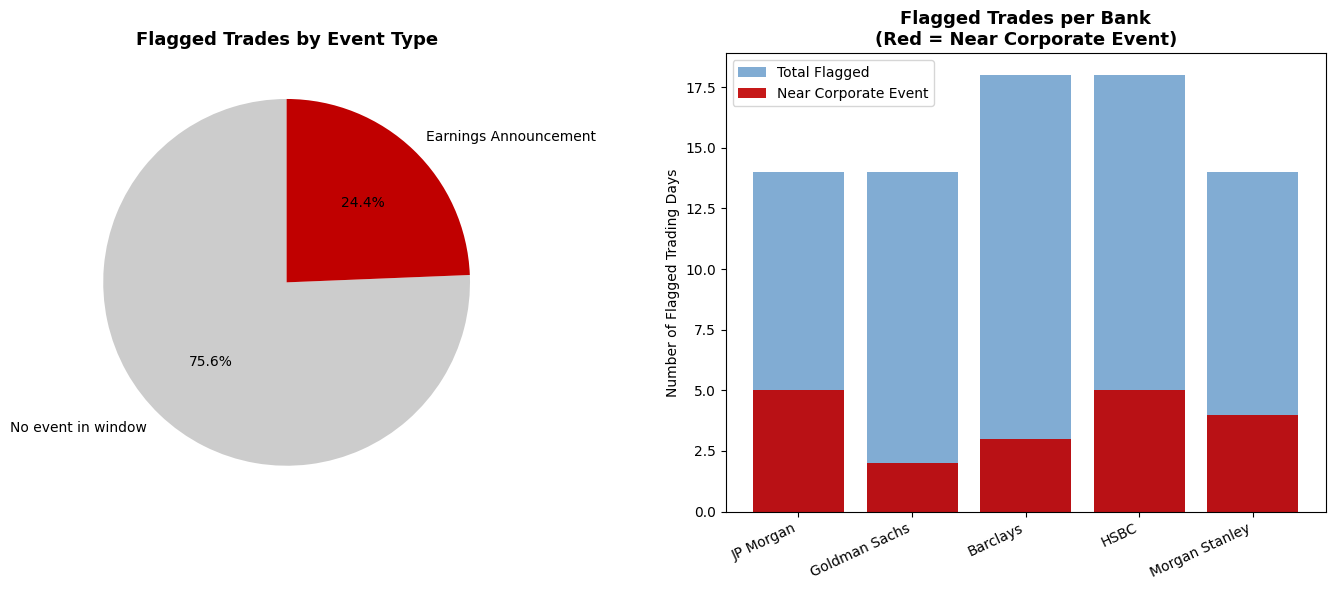

✅ Results saved to data/flagged_trades_correlated.csv
✅ Chart saved to data/correlation_analysis.png

📊 KEY FINDING:
   24.4% of suspicious trading days occurred within
   5 days of a major corporate announcement — consistent
   with FCA MAR Article 8 insider dealing patterns.


In [17]:
# Save full results
corr_df.to_csv('../data/flagged_trades_correlated.csv', index=False)

# ── Chart: Correlation breakdown ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart — event type breakdown
event_counts = corr_df['event_type'].value_counts()
colours = ['#C00000' if 'Earnings' in e else '#2E75B6' if 'Dividend' in e else '#CCCCCC' 
           for e in event_counts.index]
axes[0].pie(event_counts.values, labels=event_counts.index,
            autopct='%1.1f%%', colors=colours, startangle=90)
axes[0].set_title('Flagged Trades by Event Type', fontweight='bold', fontsize=13)

# Bar chart — flagged days per bank with event correlation
banks_order = ['JP Morgan', 'Goldman Sachs', 'Barclays', 'HSBC', 'Morgan Stanley']
total_per_bank      = corr_df.groupby('bank').size().reindex(banks_order, fill_value=0)
correlated_per_bank = corr_df[corr_df['event_type'] != 'No event in window'].groupby('bank').size().reindex(banks_order, fill_value=0)

x = range(len(banks_order))
axes[1].bar(x, total_per_bank.values,      color='#2E75B6', alpha=0.6, label='Total Flagged')
axes[1].bar(x, correlated_per_bank.values, color='#C00000', alpha=0.9, label='Near Corporate Event')
axes[1].set_xticks(x)
axes[1].set_xticklabels(banks_order, rotation=25, ha='right', fontsize=10)
axes[1].set_ylabel('Number of Flagged Trading Days')
axes[1].set_title('Flagged Trades per Bank\n(Red = Near Corporate Event)', fontweight='bold', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results saved to data/flagged_trades_correlated.csv")
print("✅ Chart saved to data/correlation_analysis.png")
print(f"\n📊 KEY FINDING:")
print(f"   {pct_correlated}% of suspicious trading days occurred within")
print(f"   5 days of a major corporate announcement — consistent")
print(f"   with FCA MAR Article 8 insider dealing patterns.")